# Content Popularity Analysis: Social Buzz

**Context:** Social Buzz is a fast-growing social media platform that receives over 100,000 posts per day. As part of a 3-month engagement, Accenture was asked for *"an analysis of their content categories showing the top 5 categories with the largest aggregate popularity"*.

Popularity follows the client's scoring model. Each reaction type (for example love or disgust) has a score from 0 to 75, and a category's popularity is the sum of the scores of all reactions to its posts.

**Data model** (see [`brief/data-model.pdf`](brief/data-model.pdf)):
- `Content.csv`: one row per post, with its type and category
- `Reactions.csv`: one row per reaction to a post
- `ReactionTypes.csv`: sentiment and score of each reaction type

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4.5)

content = pd.read_csv("data/Content.csv")
reactions = pd.read_csv("data/Reactions.csv")
reaction_types = pd.read_csv("data/ReactionTypes.csv")

for name, df in [("Content", content), ("Reactions", reactions), ("ReactionTypes", reaction_types)]:
    print(f"{name:<14} {df.shape[0]:>6,} rows  columns: {list(df.columns)}")

Content         1,000 rows  columns: ['Unnamed: 0', 'Content ID', 'User ID', 'Type', 'Category', 'URL']
Reactions      25,553 rows  columns: ['Unnamed: 0', 'Content ID', 'User ID', 'Type', 'Datetime']
ReactionTypes      16 rows  columns: ['Unnamed: 0', 'Type', 'Sentiment', 'Score']


## 2. Cleaning

### 2.1 Drop columns not needed for the analysis
`Unnamed: 0` is an exported index; `User ID` and `URL` are not used to measure popularity.

In [2]:
content = content.drop(columns=["Unnamed: 0", "User ID", "URL"]).rename(columns={"Type": "Content Type"})
reactions = reactions.drop(columns=["Unnamed: 0", "User ID"]).rename(columns={"Type": "Reaction Type"})
reaction_types = reaction_types.drop(columns=["Unnamed: 0"]).rename(columns={"Type": "Reaction Type"})

### 2.2 Missing values

In [3]:
print("Content:", content.isna().sum().to_dict())
print("Reactions:", reactions.isna().sum().to_dict())

Content: {'Content ID': 0, 'Content Type': 0, 'Category': 0}
Reactions: {'Content ID': 0, 'Reaction Type': 980, 'Datetime': 0}


Reactions without a type can't be scored, so they are removed.

In [4]:
print(f"Dropping {reactions['Reaction Type'].isna().sum():,} reactions with no type")
reactions = reactions.dropna(subset=["Reaction Type"])
reactions["Datetime"] = pd.to_datetime(reactions["Datetime"])

Dropping 980 reactions with no type


### 2.3 Inconsistent category labels

The same category appears with several spellings:

In [5]:
print(f"Distinct raw categories: {content['Category'].nunique()}")
sorted(content["Category"].unique(), key=lambda s: s.strip('"').lower())

Distinct raw categories: 41


['Animals',
 'animals',
 '"animals"',
 'cooking',
 '"cooking"',
 'culture',
 '"culture"',
 'Culture',
 'dogs',
 '"dogs"',
 'education',
 'Education',
 'fitness',
 'Fitness',
 'food',
 '"food"',
 'Food',
 'healthy eating',
 'Healthy Eating',
 'public speaking',
 '"public speaking"',
 'Public Speaking',
 'science',
 'Science',
 '"science"',
 'soccer',
 '"soccer"',
 'Soccer',
 'Studying',
 'studying',
 '"studying"',
 'technology',
 'Technology',
 '"technology"',
 'tennis',
 '"tennis"',
 'travel',
 'Travel',
 'veganism',
 'Veganism',
 '"veganism"']

`animals`, `Animals` and `"animals"` are the same category. If they are not merged, its score is split across three groups, and this changes the top 5. The labels are fixed by removing quotes and converting to lower case.

In [6]:
content["Category"] = content["Category"].str.strip('"').str.strip().str.lower()
print(f"Distinct categories after cleaning: {content['Category'].nunique()}")
sorted(content["Category"].unique())

Distinct categories after cleaning: 16


['animals',
 'cooking',
 'culture',
 'dogs',
 'education',
 'fitness',
 'food',
 'healthy eating',
 'public speaking',
 'science',
 'soccer',
 'studying',
 'technology',
 'tennis',
 'travel',
 'veganism']

## 3. Build the analysis table

In [7]:
df = (
    reactions
    .merge(content, on="Content ID", how="inner", validate="many_to_one")
    .merge(reaction_types, on="Reaction Type", how="left", validate="many_to_one")
)
assert df["Score"].notna().all(), "Some reactions have no score"
print(f"{len(df):,} scored reactions from {df['Content ID'].nunique():,} posts, "
      f"{df['Datetime'].min():%b %Y} to {df['Datetime'].max():%b %Y}")
df.head()

24,573 scored reactions from 962 posts, Jun 2020 to Jun 2021


,Content ID,Reaction Type,Datetime,Content Type,Category,Sentiment,Score
0,97522e57-d9ab-4bd6-97bf-c24d952602d2,disgust,2020-11-07 09:43:50,photo,studying,negative,0
1,97522e57-d9ab-4bd6-97bf-c24d952602d2,dislike,2021-06-17 12:22:51,photo,studying,negative,10
2,97522e57-d9ab-4bd6-97bf-c24d952602d2,scared,2021-04-18 05:13:58,photo,studying,negative,15
3,97522e57-d9ab-4bd6-97bf-c24d952602d2,disgust,2021-01-06 19:13:01,photo,studying,negative,0
4,97522e57-d9ab-4bd6-97bf-c24d952602d2,interested,2020-08-23 12:25:58,photo,studying,positive,30


## 4. Top 5 categories by popularity

In [8]:
by_category = (
    df.groupby("Category")
    .agg(score=("Score", "sum"), reactions=("Score", "size"), posts=("Content ID", "nunique"))
    .assign(score_share=lambda d: d["score"] / d["score"].sum(),
            score_per_reaction=lambda d: d["score"] / d["reactions"])
    .sort_values("score", ascending=False)
)
by_category.to_csv("data/most_popular_categories.csv")
by_category.head(10)

,score,reactions,posts,score_share,score_per_reaction
Category,,,,,
animals,74965,1897,69,0.076994,39.517659
science,71168,1796,67,0.073094,39.625835
healthy eating,69339,1717,60,0.071216,40.383809
technology,68738,1698,68,0.070599,40.481743
food,66676,1699,62,0.068481,39.244261
culture,66579,1676,65,0.068381,39.724940
travel,64880,1647,69,0.066636,39.392835
cooking,64756,1664,60,0.066509,38.915865
soccer,57783,1457,63,0.059347,39.658888


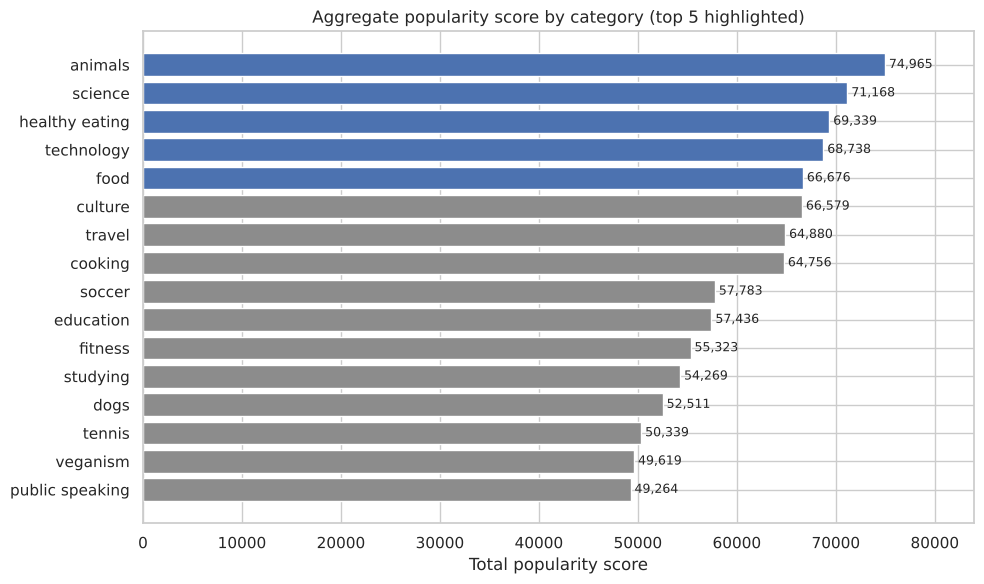

In [9]:
top5 = by_category.head(5).index

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["C0" if c in top5 else "C7" for c in by_category.index]
ax.barh(by_category.index[::-1], by_category["score"][::-1], color=colors[::-1])
for i, (cat, row) in enumerate(by_category[::-1].iterrows()):
    ax.text(row["score"] + 400, i, f"{row['score']:,.0f}", va="center", fontsize=9)
ax.set(title="Aggregate popularity score by category (top 5 highlighted)", xlabel="Total popularity score")
ax.set_xlim(0, by_category["score"].max() * 1.12)
plt.tight_layout()
plt.show()

In [10]:
by_category.head(5).assign(score_share=lambda d: d["score_share"].map("{:.1%}".format))[["score", "score_share", "reactions", "posts"]]

,score,score_share,reactions,posts
Category,,,,
animals,74965,7.7%,1897,69
science,71168,7.3%,1796,67
healthy eating,69339,7.1%,1717,60
technology,68738,7.1%,1698,68
food,66676,6.8%,1699,62


The top 5 are Animals, Science, Healthy eating, Technology and Food.

The differences at the top are small: each of the top 5 has about 7% to 8% of total popularity. The average score per reaction is similar across categories, so the ranking depends mostly on the number of reactions:

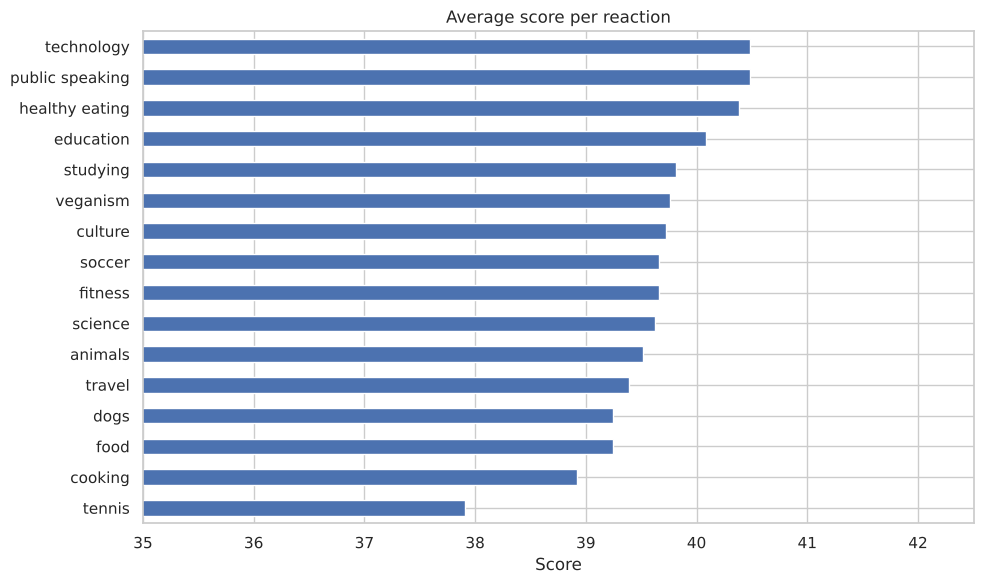

In [11]:
ax = by_category["score_per_reaction"].sort_values().plot.barh(color="C0", figsize=(10, 6))
ax.set(title="Average score per reaction", xlabel="Score", ylabel="")
ax.set_xlim(35, None)
plt.tight_layout()
plt.show()

## 5. What kind of reactions do the top categories get?

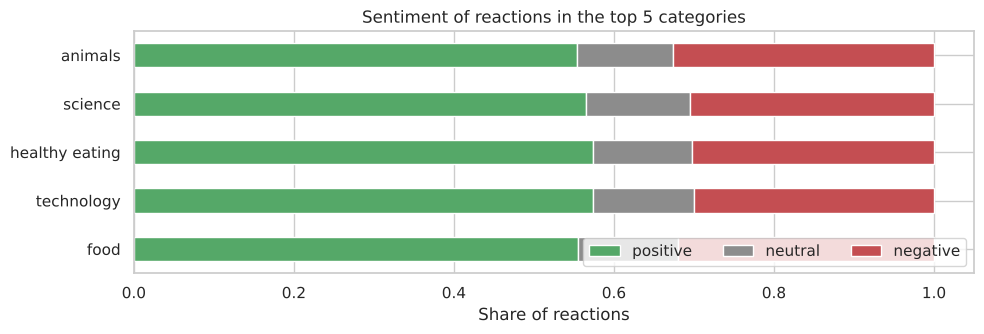

In [12]:
sentiment = (
    pd.crosstab(df["Category"], df["Sentiment"], normalize="index")
    .loc[top5, ["positive", "neutral", "negative"]]
)
ax = sentiment.plot.barh(stacked=True, color=["C2", "C7", "C3"], figsize=(10, 3.5))
ax.set(title="Sentiment of reactions in the top 5 categories", xlabel="Share of reactions", ylabel="")
ax.invert_yaxis()
ax.legend(loc="lower right", ncol=3)
plt.tight_layout()
plt.show()

## 6. Content type and activity over time

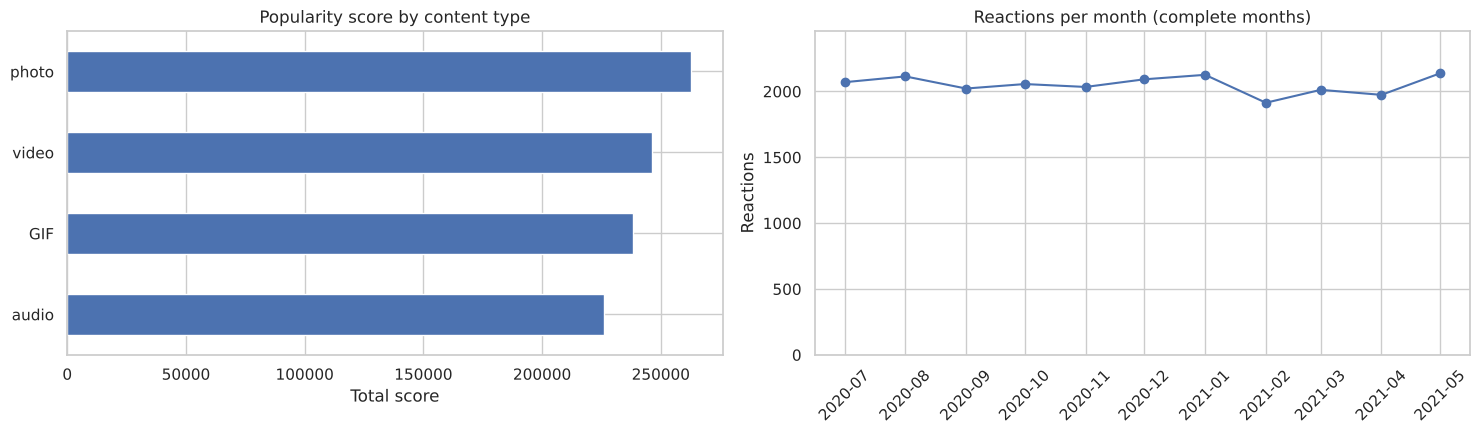

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

df.groupby("Content Type")["Score"].sum().sort_values().plot.barh(ax=axes[0], color="C0")
axes[0].set(title="Popularity score by content type", xlabel="Total score", ylabel="")

monthly = df.set_index("Datetime").resample("MS").size()
full_months = monthly.iloc[1:-1]   # first and last months are partial
axes[1].plot(full_months.index, full_months.values, marker="o")
axes[1].set(title="Reactions per month (complete months)", ylabel="Reactions", ylim=(0, full_months.max() * 1.15))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [14]:
print(f"Busiest month: {full_months.idxmax():%B %Y} ({full_months.max():,} reactions)")

Busiest month: May 2021 (2,138 reactions)


Photos have the highest total score, but the gap between content types is small. Monthly activity is stable at about 2,000 reactions, with no clear seasonality. May 2021 is slightly ahead of the other months.

## 7. Conclusions

- The top 5 categories by total popularity are Animals, Science, Healthy eating, Technology and Food.
- Food appears twice in the top 5 (Healthy eating and Food), and Cooking is 8th. Campaigns or partnerships with food and healthy eating brands are a good fit.
- The average score per reaction is similar across categories, so more posts in the top categories is the most direct way to grow engagement.
- Before the category labels were cleaned, Cooking was in the top 5 and Food was not. The client should use a fixed list of categories at upload.

**Next steps:** track each category's popularity over time, and compare the score per post to separate engagement from posting volume.